# Домашнее задание. Библиотека sklearn и классификация с помощью KNN

**Задача**: предсказать, выживет ли персонаж из Игры Престолов (`isAlive`).

**Метрика**: Accuracy

## Часть 1. Анализ и предобработка данных

### Задание 1.1. Импорт библиотек

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

RANDOM_STATE = 42

### Загрузка данных

In [2]:
os.makedirs('data', exist_ok=True)

gdown.download(id='1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v', output='data/game_of_thrones_train.csv', quiet=False)
gdown.download(id='1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3', output='data/game_of_thrones_test.csv', quiet=False)
gdown.download(id='1M14conWjAW2QLoyCXbHEAy8bql2f99eF', output='data/submission.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /Users/yarkiy/Documents/GitHub/MFTI/4.1 Домашнее задание. Основы машинного обучения/data/game_of_thrones_train.csv


  0%|          | 0.00/138k [00:00<?, ?B/s]

100%|██████████| 138k/138k [00:00<00:00, 576kB/s]

100%|██████████| 138k/138k [00:00<00:00, 574kB/s]

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /Users/yarkiy/Documents/GitHub/MFTI/4.1 Домашнее задание. Основы машинного обучения/data/game_of_thrones_test.csv


...

100%|██████████| 37.3k/37.3k [00:00<00:00, 296kB/s]

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /Users/yarkiy/Documents/GitHub/MFTI/4.1 Домашнее задание. Основы машинного обучения/data/submission.csv


  0%|          | 0.00/2.74k [00:00<?, ?B/s]

100%|██████████| 2.74k/2.74k [00:00<00:00, 2.25MB/s]

'data/submission.csv'

### Задание 1.2. Загрузка датасета в DataFrame

In [3]:
data = pd.read_csv('data/game_of_thrones_train.csv', index_col='S.No')
data_test = pd.read_csv('data/game_of_thrones_test.csv', index_col='S.No')

print(f'Train: {data.shape}')
print(f'Test: {data_test.shape}')
data.head()

Train: (1557, 25)
Test: (389, 24)


,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   str    
 1   title             717 non-null    str    
 2   male              1557 non-null   int64  
 3   culture           488 non-null    str    
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     str    
 6   father            22 non-null     str    
 7   heir              21 non-null     str    
 8   house             1176 non-null   str    
 9   spouse            200 non-null    str    
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  isAliv

In [5]:
# Статистика по категориальным признакам
data.describe(include='object').T

,count,unique,top,freq
name,1557,1557,Viserys II Targaryen,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


In [6]:
# Статистика по числовым признакам — проверяем адекватность значений
data.describe(include=[np.number]).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


### Задание 1.3. Предобработка (очистка) данных

Анализ пропущенных значений. Удалять строки с NaN не будем — слишком много пропусков.

In [7]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(1)
pd.DataFrame({'Пропуски': missing, '%': missing_pct}).query('Пропуски > 0').sort_values('%', ascending=False)

,Пропуски,%
mother,1539,98.8
isAliveMother,1539,98.8
heir,1536,98.7
isAliveHeir,1536,98.7
father,1535,98.6
isAliveFather,1535,98.6
spouse,1357,87.2
isAliveSpouse,1357,87.2
dateOfBirth,1278,82.1
age,1278,82.1


**Выводы по пропускам:**
- `mother`, `father`, `heir`, `isAliveMother/Father/Heir` — 98%+ пропусков, **удаляем** (слишком мало данных)
- `spouse`, `isAliveSpouse` — 87% пропусков, обработаем по аналогии с age (значение + индикатор наличия)
- `dateOfBirth`, `age` — 82% пропусков, обработаем специальным образом (age_value + age_no_data)
- `culture` — 69% пропусков, **группируем** по словарю из задания и применяем one-hot кодирование
- `title` — 54% пропусков, **удаляем** (высокая кардинальность)
- `house` — 25% пропусков, **не используем** (315 уникальных — слишком высокая кардинальность)

Заполнять медианой/средним при 80%+ пропусков — плохая идея. Вместо этого используем подход с индикатором пропуска.

### Задание 1.4. Числовые признаки

**Признак popularity** — гистограмма распределения.

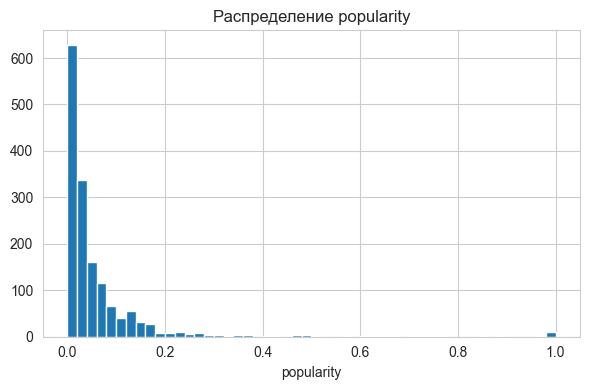

Popularity: min=0.0000, max=1.0000


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
data['popularity'].hist(bins=50, ax=ax)
ax.set_title('Распределение popularity')
ax.set_xlabel('popularity')
plt.tight_layout()
plt.show()

print(f"Popularity: min={data['popularity'].min():.4f}, max={data['popularity'].max():.4f}")

Распределение сильно скошено вправо. Применяем логарифмическое преобразование, как рекомендует задание: `np.log10(popularity * M + 1)` с M=100. Это растягивает плотную область низких значений, что полезно для линейных моделей.

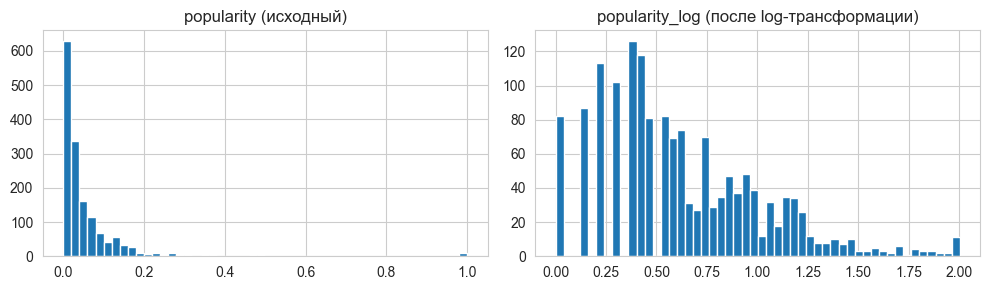

In [9]:
# Логарифмическое преобразование popularity (рекомендация задания)
M = 100
data['popularity_log'] = np.log10(data['popularity'] * M + 1)
data_test['popularity_log'] = np.log10(data_test['popularity'] * M + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
data['popularity'].hist(bins=50, ax=axes[0])
axes[0].set_title('popularity (исходный)')
data['popularity_log'].hist(bins=50, ax=axes[1])
axes[1].set_title('popularity_log (после log-трансформации)')
plt.tight_layout()
plt.show()

**Признак numDeadRelations** — создаём бинарный `boolDeadRelations`.

In [10]:
print('Распределение numDeadRelations:')
print(data['numDeadRelations'].value_counts().sort_index())

# Бинарный признак: были ли мёртвые родственники
data['boolDeadRelations'] = (data['numDeadRelations'] > 0).astype(int)
data_test['boolDeadRelations'] = (data_test['numDeadRelations'] > 0).astype(int)

Распределение numDeadRelations:
numDeadRelations
0     1488
1       24
2        4
3        4
4        7
5       10
6        3
7        7
8        2
9        1
10       4
11       1
12       1
15       1
Name: count, dtype: int64


**Признак age** — разделяем на `age_value` и `age_no_data`.

Там, где возраст указан: `age_value` = age, `age_no_data` = 0.
Там, где не указан: `age_value` = 0, `age_no_data` = 1.

In [11]:
data['age_value'] = data['age'].fillna(0)
data['age_no_data'] = data['age'].isnull().astype(int)

data_test['age_value'] = data_test['age'].fillna(0)
data_test['age_no_data'] = data_test['age'].isnull().astype(int)

**Признак isAliveSpouse** — 87% пропусков, но информация о наличии/отсутствии данных сама по себе важна.
По аналогии с age создаём два признака: значение и индикатор наличия данных.

In [12]:
# isAliveSpouse: два признака по аналогии с age
data['spouse_alive_value'] = data['isAliveSpouse'].fillna(0).astype(int)
data['spouse_alive_known'] = data['isAliveSpouse'].notna().astype(int)

data_test['spouse_alive_value'] = data_test['isAliveSpouse'].fillna(0).astype(int)
data_test['spouse_alive_known'] = data_test['isAliveSpouse'].notna().astype(int)

# Проверяем связь с целевой переменной
print('isAliveSpouse → isAlive:')
print(data.groupby('isAliveSpouse', dropna=False)['isAlive'].agg(['mean', 'count']))
print()
print('spouse_alive_known → isAlive:')
print(data.groupby('spouse_alive_known')['isAlive'].agg(['mean', 'count']))

isAliveSpouse → isAlive:
                   mean  count
isAliveSpouse                 
0.0            0.619048     42
1.0            0.753165    158
NaN            0.786293   1357

spouse_alive_known → isAlive:
                        mean  count
spouse_alive_known                 
0                   0.786293   1357
1                   0.725000    200


### Исправление ошибок в тестовых данных

В тестовых данных есть строки с аномально отрицательными значениями age (ошибки ввода).

In [13]:
# Проверяем аномалии в тестовых данных
neg_age = data_test.loc[data_test['age'] < 0]
if len(neg_age) > 0:
    print('Строки с отрицательным возрастом:')
    print(neg_age[['age', 'dateOfBirth']])
    
    # Исправляем: это явные ошибки ввода (278279 -> 278, 298299 -> 299)
    for idx in neg_age.index:
        data_test.loc[idx, 'age'] = 0.
        data_test.loc[idx, 'age_value'] = 0.
else:
    print('Аномалий в возрасте не обнаружено')

Строки с отрицательным возрастом:
           age  dateOfBirth
S.No                       
1685 -277980.0     278279.0
1869 -298001.0     298299.0


### Задание 1.5. Категориальные признаки

**Признак culture** — анализ распределения.

In [14]:
print('Уникальные значения culture:')
print(data['culture'].value_counts(dropna=False).head(20))

Уникальные значения culture:
culture
NaN                    1069
Northmen                 94
Ironborn                 91
Free Folk                45
Braavosi                 39
Valyrian                 28
Dornish                  17
Dothraki                 17
Ghiscari                 17
Reach                    13
Vale mountain clans      12
Rivermen                 10
Valemen                  10
northmen                  9
Westerman                 8
Free folk                 7
Tyroshi                   6
Qartheen                  5
Summer Isles              4
Astapori                  4
Name: count, dtype: int64


In [15]:
# Словарь группировки народов из задания
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

# Инвертируем словарь
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
    for v in cultures_grouped[k]:
        cultures_grouped_inverted.update({v: k})

data['culture_grouped'] = data['culture'].str.lower().str.strip().map(cultures_grouped_inverted)
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')

data_test['culture_grouped'] = data_test['culture'].str.lower().str.strip().map(cultures_grouped_inverted)
data_test['culture_grouped'] = data_test['culture_grouped'].fillna('culture_no_data')

print('Распределение сгруппированных культур (train):')
print(data['culture_grouped'].value_counts())

Распределение сгруппированных культур (train):
culture_grouped
culture_no_data              1069
Essos Nations                 109
the North                     108
the Iron Islands               95
Other Nations                  57
Old Nations                    32
the Mountain and the Vale      25
Dorne                          21
the Rock                       14
the Reach                      13
the Isles and Rivers           10
the Stormlands                  4
Name: count, dtype: int64


Группировка culture даёт 12 категорий (включая `culture_no_data`). Применяем one-hot кодирование с `drop_first=True` для устранения мультиколлинеарности. L1-регуляризация LogisticRegression автоматически обнулит неинформативные признаки.

In [16]:
# One-hot кодирование culture_grouped
culture_dummies_train = pd.get_dummies(data['culture_grouped'], prefix='cult', drop_first=True, dtype=int)
culture_dummies_test = pd.get_dummies(data_test['culture_grouped'], prefix='cult', drop_first=True, dtype=int)

# Выравниваем колонки train и test (в test могут отсутствовать некоторые категории)
culture_dummies_test = culture_dummies_test.reindex(columns=culture_dummies_train.columns, fill_value=0)

print(f'Culture one-hot: {culture_dummies_train.shape[1]} признаков')
print(culture_dummies_train.columns.tolist())

Culture one-hot: 11 признаков
['cult_Essos Nations', 'cult_Old Nations', 'cult_Other Nations', 'cult_culture_no_data', 'cult_the Iron Islands', 'cult_the Isles and Rivers', 'cult_the Mountain and the Vale', 'cult_the North', 'cult_the Reach', 'cult_the Rock', 'cult_the Stormlands']


### Задание 1.6. Числовые признаки — количество уникальных значений

In [17]:
print('Количество уникальных значений по столбцам:')
print(data.nunique().sort_values())

Количество уникальных значений по столбцам:
isAliveMother            2
book5                    2
book4                    2
book3                    2
book2                    2
book1                    2
isAliveHeir              2
spouse_alive_known       2
isAliveSpouse            2
isNoble                  2
isAlive                  2
boolDeadRelations        2
age_no_data              2
male                     2
spouse_alive_value       2
isMarried                2
isAliveFather            2
culture_grouped         12
numDeadRelations        14
mother                  16
father                  19
heir                    20
culture                 51
age                     72
age_value               72
dateOfBirth            105
popularity             117
popularity_log         117
spouse                 186
title                  195
house                  315
name                  1557
dtype: int64


Бинарные признаки (2 уникальных значения): `male`, `book1`-`book5`, `isMarried`, `isNoble`, `isAlive`.
Непрерывные: `popularity`, `age`, `numDeadRelations`.
Все остальные — категориальные с высокой кардинальностью.

### Задание 1.7-1.8. Анализ признаков и влияние на целевую переменную

Распределение isAlive:
isAlive
1    1212
0     345
Name: count, dtype: int64
Доля живых: 0.778


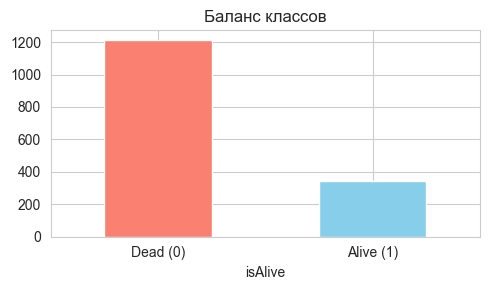

In [18]:
# Баланс целевой переменной
print('Распределение isAlive:')
print(data['isAlive'].value_counts())
print(f'Доля живых: {data["isAlive"].mean():.3f}')

fig, ax = plt.subplots(figsize=(5, 3))
data['isAlive'].value_counts().plot(kind='bar', ax=ax, color=['salmon', 'skyblue'])
ax.set_title('Баланс классов')
ax.set_xticklabels(['Dead (0)', 'Alive (1)'], rotation=0)
plt.tight_layout()
plt.show()

Корреляция признаков с isAlive:
book4                 0.284014
popularity_log       -0.242497
numDeadRelations     -0.198876
age_value            -0.181938
boolDeadRelations    -0.178177
male                 -0.148290
age_no_data           0.113629
book1                -0.112468
isNoble              -0.060572
book2                -0.055998
isMarried            -0.049381
spouse_alive_known   -0.049381
book5                 0.032531
spouse_alive_value   -0.020436
book3                 0.018427
Name: isAlive, dtype: float64


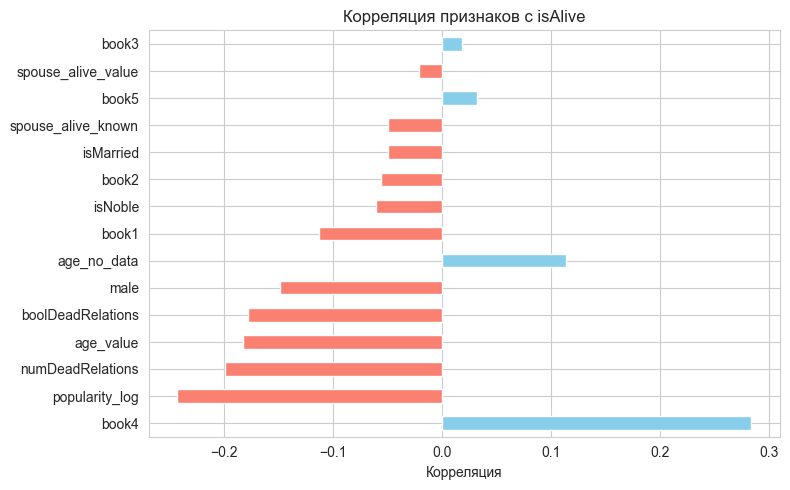

In [19]:
# Корреляция числовых признаков с isAlive
numeric_for_corr = [
    'male', 'book1', 'book2', 'book3', 'book4', 'book5',
    'isMarried', 'isNoble', 'numDeadRelations', 'popularity_log',
    'boolDeadRelations', 'age_value', 'age_no_data',
    'spouse_alive_value', 'spouse_alive_known', 'isAlive'
]

corr_with_target = data[numeric_for_corr].corr()['isAlive'].drop('isAlive').sort_values(key=abs, ascending=False)
print('Корреляция признаков с isAlive:')
print(corr_with_target)

fig, ax = plt.subplots(figsize=(8, 5))
corr_with_target.plot(kind='barh', ax=ax, color=['salmon' if v < 0 else 'skyblue' for v in corr_with_target])
ax.set_title('Корреляция признаков с isAlive')
ax.set_xlabel('Корреляция')
plt.tight_layout()
plt.show()

In [20]:
# Сравнение средних isAlive для бинарных признаков
binary_cols = ['male', 'book1', 'book2', 'book3', 'book4', 'book5',
               'isMarried', 'isNoble', 'boolDeadRelations', 'age_no_data',
               'spouse_alive_known']

for col in binary_cols:
    alive_rate = data.groupby(col)['isAlive'].mean()
    print(f'{col}: 0 -> {alive_rate[0]:.3f}, 1 -> {alive_rate[1]:.3f} (разница {abs(alive_rate[1]-alive_rate[0]):.3f})')

male: 0 -> 0.852, 1 -> 0.727 (разница 0.125)
book1: 0 -> 0.797, 1 -> 0.662 (разница 0.135)
book2: 0 -> 0.795, 1 -> 0.745 (разница 0.050)
book3: 0 -> 0.772, 1 -> 0.787 (разница 0.015)
book4: 0 -> 0.645, 1 -> 0.882 (разница 0.238)
book5: 0 -> 0.769, 1 -> 0.798 (разница 0.029)
isMarried: 0 -> 0.786, 1 -> 0.725 (разница 0.061)
isNoble: 0 -> 0.801, 1 -> 0.750 (разница 0.051)
boolDeadRelations: 0 -> 0.794, 1 -> 0.435 (разница 0.360)
age_no_data: 0 -> 0.677, 1 -> 0.800 (разница 0.123)
spouse_alive_known: 0 -> 0.786, 1 -> 0.725 (разница 0.061)


**Самые информативные признаки:**
- `boolDeadRelations`: наличие мёртвых родственников сильно снижает шансы выжить (0.79 → 0.43)
- `book4`: появление в 4-й книге сильно повышает шансы (0.64 → 0.88)
- `male`: мужчины выживают реже (0.85 → 0.73)
- `age_no_data`: персонажи без указанного возраста чаще живы (0.68 → 0.80)

### Задание 1.9-1.10. Формирование X, y и разделение на train/val

In [21]:
# Финальный набор признаков: числовые + culture one-hot
feature_cols_numeric = [
    'male', 'book1', 'book2', 'book3', 'book4', 'book5',
    'isMarried', 'isNoble',
    'numDeadRelations', 'boolDeadRelations',
    'popularity_log',
    'age_value', 'age_no_data',
    'spouse_alive_value', 'spouse_alive_known',
]

# Числовые признаки
X_numeric = data[feature_cols_numeric].fillna(0)
X_test_numeric = data_test[feature_cols_numeric].fillna(0)

# Объединяем с culture one-hot
X_full = pd.concat([X_numeric.reset_index(drop=True), culture_dummies_train.reset_index(drop=True)], axis=1)
X_test_full = pd.concat([X_test_numeric.reset_index(drop=True), culture_dummies_test.reset_index(drop=True)], axis=1)

X = X_full.values
y = data['isAlive'].values
X_test_final = X_test_full.values

all_feature_names = list(X_full.columns)

print(f'X: {X.shape}, y: {y.shape}')
print(f'X_test: {X_test_final.shape}')
print(f'NaN: X={np.isnan(X).sum()}, X_test={np.isnan(X_test_final).sum()}')
print(f'\nВсе признаки ({len(all_feature_names)}):')
print(all_feature_names)

X: (1557, 26), y: (1557,)
X_test: (389, 26)
NaN: X=0, X_test=0

Все признаки (26):
['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried', 'isNoble', 'numDeadRelations', 'boolDeadRelations', 'popularity_log', 'age_value', 'age_no_data', 'spouse_alive_value', 'spouse_alive_known', 'cult_Essos Nations', 'cult_Old Nations', 'cult_Other Nations', 'cult_culture_no_data', 'cult_the Iron Islands', 'cult_the Isles and Rivers', 'cult_the Mountain and the Vale', 'cult_the North', 'cult_the Reach', 'cult_the Rock', 'cult_the Stormlands']


In [22]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')
print(f'Баланс классов train: {np.mean(y_train):.3f}')
print(f'Баланс классов val:   {np.mean(y_val):.3f}')

X_train: (1245, 26), X_val: (312, 26)
Баланс классов train: 0.778
Баланс классов val:   0.779


In [23]:
# Масштабирование теперь внутри Pipeline — отдельный scaler не нужен
# (Pipeline автоматически fit на train и transform на val/test)
print('Масштабирование встроено в Pipeline — отдельный StandardScaler не требуется')

Масштабирование встроено в Pipeline — отдельный StandardScaler не требуется


## Часть 2. Обучение моделей

### Задание 2.1-2.2. Обучение нескольких моделей

Используем 3 модели из списка, рекомендованного заданием:
1. **LogisticRegression** — основная модель, рекомендованная заданием
2. **KNeighborsClassifier** — метод ближайших соседей
3. **DecisionTreeClassifier** — дерево решений

**Важно**: используем `Pipeline(StandardScaler + модель)` внутри `GridSearchCV`, чтобы масштабирование происходило только на train-фолдах и не было утечки данных.

In [24]:
# Модель 1: Logistic Regression с Pipeline (рекомендуемая в задании)
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver='liblinear'))
])

# Предварительная оценка на train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_val)
acc_lr = accuracy_score(y_val, y_pred_lr)
print(f'Logistic Regression Accuracy (val): {acc_lr:.4f}')

Logistic Regression Accuracy (val): 0.7724


In [25]:
# Модель 2: KNN с Pipeline
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=15))
])

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_val)
acc_knn = accuracy_score(y_val, y_pred_knn)
print(f'KNN (k=15) Accuracy (val): {acc_knn:.4f}')

KNN (k=15) Accuracy (val): 0.7692


In [26]:
# Модель 3: Decision Tree (не требует масштабирования)
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_val)
acc_dt = accuracy_score(y_val, y_pred_dt)
print(f'Decision Tree Accuracy (val): {acc_dt:.4f}')

Decision Tree Accuracy (val): 0.7853


### Сравнение моделей

             Модель  Accuracy (val)
      Decision Tree        0.785256
Logistic Regression        0.772436
         KNN (k=15)        0.769231


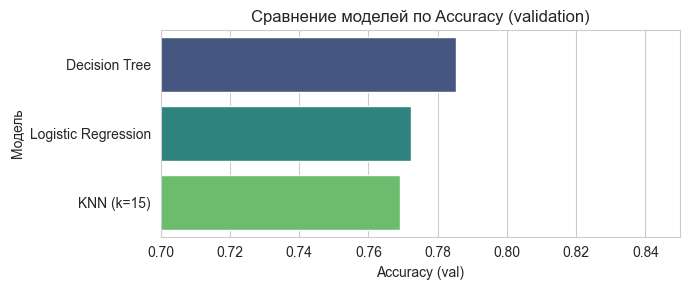

In [27]:
results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'KNN (k=15)', 'Decision Tree'],
    'Accuracy (val)': [acc_lr, acc_knn, acc_dt]
}).sort_values('Accuracy (val)', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
sns.barplot(data=results, x='Accuracy (val)', y='Модель', ax=ax, palette='viridis')
ax.set_title('Сравнение моделей по Accuracy (validation)')
ax.set_xlim(0.7, 0.85)
plt.tight_layout()
plt.show()

### Подбор гиперпараметров через кросс-валидацию

Используем 10-fold CV с **Pipeline** внутри GridSearchCV — масштабирование происходит внутри каждого фолда, без утечки данных.

In [28]:
# GridSearch для LogReg с Pipeline (без утечки данных!)
pipe_lr_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver='liblinear'))
])

param_grid_lr = {
    'lr__C': [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 5.0, 10.0],
    'lr__penalty': ['l1', 'l2'],
}

grid_lr = GridSearchCV(pipe_lr_cv, param_grid_lr, cv=10, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X, y)

print(f'LogReg лучшие параметры: {grid_lr.best_params_}')
print(f'LogReg лучший CV-10 Accuracy: {grid_lr.best_score_:.4f}')

# Топ-5 конфигураций
cv_df = pd.DataFrame(grid_lr.cv_results_)[['param_lr__C', 'param_lr__penalty', 'mean_test_score', 'std_test_score']]
cv_df = cv_df.sort_values('mean_test_score', ascending=False).head(5)
print('\nТоп-5 конфигураций LogReg:')
print(cv_df.to_string(index=False))

LogReg лучшие параметры: {'lr__C': 0.1, 'lr__penalty': 'l1'}
LogReg лучший CV-10 Accuracy: 0.8048

Топ-5 конфигураций LogReg:
 param_lr__C param_lr__penalty  mean_test_score  std_test_score
        0.10                l1         0.804752        0.026325
        0.05                l2         0.804748        0.025405
        0.50                l1         0.804748        0.023011
        0.01                l2         0.804739        0.029824
        0.05                l1         0.804739        0.023962


In [29]:
# GridSearch для KNN с Pipeline
pipe_knn_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {'knn__n_neighbors': [5, 7, 9, 11, 13, 15, 17, 21, 25, 31]}

grid_knn = GridSearchCV(pipe_knn_cv, param_grid_knn, cv=10, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X, y)

print(f'KNN лучшие параметры: {grid_knn.best_params_}')
print(f'KNN лучший CV-10 Accuracy: {grid_knn.best_score_:.4f}')

KNN лучшие параметры: {'knn__n_neighbors': 31}
KNN лучший CV-10 Accuracy: 0.8086


In [30]:
# GridSearch для Decision Tree (масштабирование не нужно)
param_grid_dt = {'max_depth': [2, 3, 4, 5, 6, 7, 8]}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=10, scoring='accuracy', n_jobs=-1
)
grid_dt.fit(X, y)

print(f'DT лучшие параметры: {grid_dt.best_params_}')
print(f'DT лучший CV-10 Accuracy: {grid_dt.best_score_:.4f}')

DT лучшие параметры: {'max_depth': 5}
DT лучший CV-10 Accuracy: 0.8067


In [31]:
# Сводная таблица CV результатов (честный CV без утечки данных)
cv_results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'KNN', 'Decision Tree'],
    'Лучшие параметры': [str(grid_lr.best_params_), str(grid_knn.best_params_), str(grid_dt.best_params_)],
    'CV-10 Accuracy': [grid_lr.best_score_, grid_knn.best_score_, grid_dt.best_score_]
}).sort_values('CV-10 Accuracy', ascending=False).reset_index(drop=True)

print(cv_results.to_string(index=False))

# Выбираем LogisticRegression — рекомендация задания, стабильное обобщение
# КNN (k=31) имеет чуть выше CV, но слишком сильно смещён к мажоритарному классу
# LogReg с L1 регуляризацией даёт более сбалансированные предсказания
best_model = grid_lr.best_estimator_
best_cv = grid_lr.best_score_
best_name = 'Logistic Regression'

print(f'\nФинальная модель: {best_name} ({grid_lr.best_params_})')
print(f'CV-10 Accuracy: {best_cv:.4f}')
print(f'Причина выбора: рекомендация задания, L1 отбирает значимые признаки, стабильное обобщение')

             Модель                    Лучшие параметры  CV-10 Accuracy
                KNN            {'knn__n_neighbors': 31}        0.808569
      Decision Tree                    {'max_depth': 5}        0.806663
Logistic Regression {'lr__C': 0.1, 'lr__penalty': 'l1'}        0.804752

Финальная модель: Logistic Regression ({'lr__C': 0.1, 'lr__penalty': 'l1'})
CV-10 Accuracy: 0.8048
Причина выбора: рекомендация задания, L1 отбирает значимые признаки, стабильное обобщение


## Часть 3. Оценка качества

### Задание 3.1. Метрики лучшей модели

In [32]:
# Оценка лучшей модели на валидационной выборке
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_val)

print(f'Accuracy на валидации: {accuracy_score(y_val, y_pred_best):.4f}')
print()
print('Classification Report:')
print(classification_report(y_val, y_pred_best, target_names=['Dead (0)', 'Alive (1)']))

Accuracy на валидации: 0.7756

Classification Report:
              precision    recall  f1-score   support

    Dead (0)       0.48      0.22      0.30        69
   Alive (1)       0.81      0.93      0.87       243

    accuracy                           0.78       312
   macro avg       0.65      0.58      0.58       312
weighted avg       0.74      0.78      0.74       312



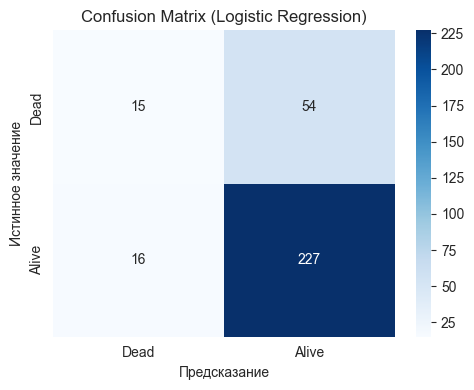

In [33]:
cm = confusion_matrix(y_val, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Dead', 'Alive'], yticklabels=['Dead', 'Alive'])
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинное значение')
ax.set_title(f'Confusion Matrix ({best_name})')
plt.tight_layout()
plt.show()

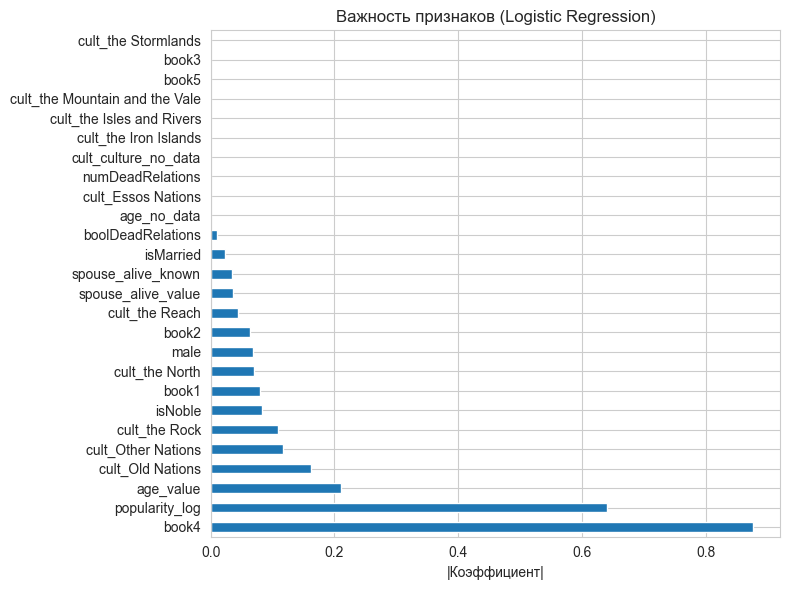

Коэффициенты модели (+ = alive, - = dead):
             popularity_log: -0.6410
                  age_value: -0.2103
           cult_Old Nations: -0.1624
         cult_Other Nations: -0.1162
              cult_the Rock: -0.1082
                    isNoble: -0.0827
                      book1: -0.0790
                       male: -0.0689
                      book2: -0.0628
          boolDeadRelations: -0.0094
  cult_the Mountain and the Vale: +0.0000
  cult_the Isles and Rivers: +0.0000
      cult_the Iron Islands: +0.0000
       cult_culture_no_data: +0.0000
         cult_Essos Nations: +0.0000
                age_no_data: +0.0000
           numDeadRelations: +0.0000
                      book5: +0.0000
                      book3: +0.0000
        cult_the Stormlands: +0.0000
                  isMarried: +0.0232
         spouse_alive_known: +0.0345
         spouse_alive_value: +0.0367
             cult_the Reach: +0.0436
             cult_the North: +0.0698
                      book4

In [34]:
# Важность признаков (если модель — LogReg или Pipeline с LogReg)
if hasattr(best_model, 'coef_'):
    model_for_coef = best_model
elif hasattr(best_model, 'named_steps') and hasattr(best_model.named_steps.get('lr', None), 'coef_'):
    model_for_coef = best_model.named_steps['lr']
else:
    model_for_coef = None

if model_for_coef is not None:
    importances = np.abs(model_for_coef.coef_[0])
    feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 6))
    feat_imp.plot(kind='barh', ax=ax)
    ax.set_title(f'Важность признаков ({best_name})')
    ax.set_xlabel('|Коэффициент|')
    plt.tight_layout()
    plt.show()

    # Коэффициенты со знаком
    coefs = pd.Series(model_for_coef.coef_[0], index=all_feature_names).sort_values()
    print('Коэффициенты модели (+ = alive, - = dead):')
    for feat, coef in coefs.items():
        print(f'  {feat:>25s}: {coef:+.4f}')
else:
    print(f'Модель {best_name} не имеет коэффициентов для анализа')

### Финальное обучение и предсказание

In [35]:
# Обучаем лучшую модель на ВСЁМ train (Pipeline сам масштабирует)
best_model.fit(X, y)
y_test_pred = best_model.predict(X_test_final)

print(f'Распределение предсказаний: 0={sum(y_test_pred==0)}, 1={sum(y_test_pred==1)}')
print(f'Доля предсказанных "alive": {np.mean(y_test_pred):.3f}')
print(f'Доля "alive" в train: {np.mean(y):.3f}')

Распределение предсказаний: 0=99, 1=290
Доля предсказанных "alive": 0.746
Доля "alive" в train: 0.778


### Генерация submission.csv

In [36]:
submission = pd.read_csv('data/submission.csv', index_col='S.No')
submission['isAlive'] = y_test_pred
submission.to_csv('submission.csv', index=True)

print(f'submission.csv создан: {submission.shape}')
print(submission.head(10))
print(f'\nРаспределение предсказаний:')
print(submission['isAlive'].value_counts())

submission.csv создан: (389, 1)
      isAlive
S.No         
1558        0
1559        1
1560        1
1561        1
1562        1
1563        1
1564        1
1565        1
1566        1
1567        1

Распределение предсказаний:
isAlive
1    290
0     99
Name: count, dtype: int64
